# Self-consistent multi-area DMFT — clean scan notebook

Rebuild of `DMFT_selfconsistent_scan.ipynb` (2-D scan, 1-D scan, catastrophe test), with two
additions:
* the **$\Lambda+\Gamma=0$ dominance line** on the $\mu$ maps — the net mean recurrent drive
  $J_{\rm within}(C_E-gC_I)+J_{\rm cross}C_{\rm cross}$ (row sum of $M_{\rm structure}$); its
  sign is inhibitory- vs excitatory-dominated and (since $\mu\approx(\Lambda+\Gamma)\langle\phi\rangle$)
  it is $\approx$ the $\mu$ sign change;
* a **$\mu$-divergence 2-D scan** (Section E$\mu$) using $\mu\to\infty$ as the ending
  criterion, to contrast with the $\Delta_0\to\infty$ criterion of Section D.

## 0. Imports and reused DMFT machinery

Activation $\phi(x)=\min\!\big(\phi_{\max},\max(0,x+\gamma)\big)$ with $\gamma=0.5$
(matches the multi-area model). Setting $\phi_{\max}=2$ reproduces the clipped
threshold-linear unit of Pan2 / Mastrogiuseppe–Ostojic for validation.

Gaussian integrals use Gauss–Hermite quadrature for the measure
$\mathcal Dz=dz\,e^{-z^2/2}/\sqrt{2\pi}$. The **primitive** $P(x)=\int_{-\infty}^x\phi$
lets us evaluate the diagonal block $Q_a(\Delta_0,\Delta_0)=\int_0^{\Delta_0}q_a\,d\Delta'
=\langle P^2\rangle-\langle P\rangle^2-\Delta_0\langle\phi\rangle^2$ with cheap 1-D
quadrature (exactly Pan2's `Prim`/`PrimSq` trick).

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  enables 3-D projection
from numpy.polynomial.hermite_e import hermegauss
from scipy.integrate import solve_ivp, cumulative_trapezoid, quad
from scipy.special import erf
from dataclasses import dataclass, replace
from itertools import product
import pickle, os

plt.rcParams['figure.dpi'] = 110

GAMMA_DEFAULT = 0.5        # threshold offset of phi
PHI_MAX_DEFAULT = np.inf   # upper bound of phi (np.inf disables saturation)
SQRT2 = np.sqrt(2.0)
GAUSS_NORM = 1.0 / np.sqrt(2.0 * np.pi)


def phi(x, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT):
    """Threshold-linear activation phi(x)=max(0,x+gamma), clipped above by phi_max."""
    y = np.maximum(0.0, x + gamma)
    if np.isfinite(phi_max):
        y = np.minimum(phi_max, y)
    return y


def phi_primitive(x, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT):
    """P(x) = int_{-gamma}^x phi(u) du, up to Pan2's irrelevant additive constant."""
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    y = x + gamma
    lin = y > 0.0
    out[lin] = 0.5 * y[lin] ** 2
    if np.isfinite(phi_max):
        sat = y > phi_max
        out[sat] = phi_max * y[sat] - 0.5 * phi_max ** 2
    return out


def make_gh_nodes(n_pts=121):
    """Nodes and weights for the Gaussian measure Dz = dz exp(-z^2/2)/sqrt(2pi)."""
    nodes, weights = hermegauss(n_pts)
    return nodes, weights / np.sqrt(2.0 * np.pi)


GH_NODES, GH_WTS = make_gh_nodes(121)


# ----------------------------------------------------------------------
# Closed-form truncated Gaussian moments (scalar `math` for speed).
# These reproduce Pan2's Phi / Prim / PrimSq exactly (verified to ~1e-14
# against the analytic formulas in cell C) at ~20x the speed of the
# array-based implementation: the inner solver loop runs millions of times.
# ----------------------------------------------------------------------
def _ncdf(x):
    return 0.5 * (1.0 + math.erf(x / SQRT2))


def _npdf(x):
    return GAUSS_NORM * math.exp(-0.5 * x * x)


def _pdf_poly(x, power):
    """x**power * N(0,1).pdf(x); 0 at +-inf and wherever the pdf underflows."""
    if not math.isfinite(x):
        return 0.0
    pdf = _npdf(x)
    if pdf == 0.0:        # |x| large: x**power * 0 -> 0 (avoid overflow in x**power)
        return 0.0
    return (x ** power) * pdf


def _trunc_z_moments(lo, hi):
    """Raw moments int_lo^hi Dz z^k for k=0..4 (scalar)."""
    i0 = _ncdf(hi) - _ncdf(lo)
    i1 = _pdf_poly(lo, 0) - _pdf_poly(hi, 0)
    i2 = i0 + _pdf_poly(lo, 1) - _pdf_poly(hi, 1)
    i3 = (_pdf_poly(lo, 2) + 2.0 * _pdf_poly(lo, 0)
          - _pdf_poly(hi, 2) - 2.0 * _pdf_poly(hi, 0))
    i4 = (3.0 * i0 + _pdf_poly(lo, 3) + 3.0 * _pdf_poly(lo, 1)
          - _pdf_poly(hi, 3) - 3.0 * _pdf_poly(hi, 1))
    return (i0, i1, i2, i3, i4)


def _trunc_y_moment(alpha, sigma, lo_y, hi_y, order):
    """E[Y**order 1_{lo_y < Y < hi_y}], Y=alpha+sigma Z (scalar)."""
    if sigma <= 0.0:
        return alpha ** order if (lo_y < alpha < hi_y) else 0.0
    lo = (lo_y - alpha) / sigma
    hi = (hi_y - alpha) / sigma
    z = _trunc_z_moments(lo, hi)
    total = 0.0
    for k in range(order + 1):
        total += math.comb(order, k) * (alpha ** (order - k)) * (sigma ** k) * z[k]
    return total


def gaussian_stats(mu, Delta0, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
                   nodes=None, wts=None):
    """Return (<phi>, <P>, <P^2>) for X~N(mu,Delta0) using closed-form Gaussian moments."""
    alpha = float(mu) + float(gamma)       # Y = X + gamma
    sigma = math.sqrt(max(float(Delta0), 0.0))

    if sigma == 0.0:
        ph = float(phi(alpha - gamma, gamma, phi_max))
        P = float(phi_primitive(alpha - gamma, gamma, phi_max))
        return ph, P, P * P

    upper = float(phi_max) if np.isfinite(phi_max) else math.inf
    y1 = _trunc_y_moment(alpha, sigma, 0.0, upper, 1)
    y2 = _trunc_y_moment(alpha, sigma, 0.0, upper, 2)
    y4 = _trunc_y_moment(alpha, sigma, 0.0, upper, 4)

    if np.isfinite(phi_max):
        m = float(phi_max)
        p_tail = _trunc_z_moments((m - alpha) / sigma, math.inf)[0]
        tail_y1 = _trunc_y_moment(alpha, sigma, m, math.inf, 1)
        tail_y2 = _trunc_y_moment(alpha, sigma, m, math.inf, 2)
        mean_ph = y1 + m * p_tail
        mean_P = 0.5 * y2 + m * tail_y1 - 0.5 * m * m * p_tail
        mean_P2 = 0.25 * y4 + m * m * tail_y2 - m ** 3 * tail_y1 + 0.25 * m ** 4 * p_tail
    else:
        mean_ph = y1
        mean_P = 0.5 * y2
        mean_P2 = 0.25 * y4

    return float(mean_ph), float(mean_P), float(mean_P2)


def mean_phi(mu, Delta0, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
             nodes=None, wts=None):
    """<phi>_a = E[phi(X)] for X ~ N(mu, Delta0)."""
    return gaussian_stats(mu, Delta0, gamma, phi_max)[0]


def Q_diag(mu, Delta0, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
           nodes=None, wts=None):
    """Q_a(Delta0,Delta0)=<P^2>-<P>^2-Delta0<phi>^2, using closed-form moments."""
    Delta0 = max(float(Delta0), 0.0)
    ph, P, P2 = gaussian_stats(mu, Delta0, gamma, phi_max)
    return float(P2 - P * P - Delta0 * ph * ph)


def C_a_gh2d(Delta, Delta0, mu, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
             nodes=None, wts=None):
    """Vectorized tensor-product Gauss-Hermite C_a kernel for full-plane scans."""
    if nodes is None:
        nodes, wts = GH_NODES, GH_WTS
    Delta0 = max(float(Delta0), 0.0)
    Delta = float(np.clip(Delta, 0.0, Delta0))
    s1 = np.sqrt(Delta)
    s2 = np.sqrt(max(Delta0 - Delta, 0.0))
    inner = phi(mu + s1 * nodes[:, None] + s2 * nodes[None, :], gamma, phi_max)
    inner_int = np.sum(wts[None, :] * inner, axis=1)
    return float(np.sum(wts * inner_int ** 2))


def C_a_adaptive_1d(Delta, Delta0, mu, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
                    epsabs=1e-10, epsrel=1e-10, limit=200):
    """Adaptive 1-D conditional-Gaussian C_a kernel; valid per area, including asymmetric systems."""
    Delta0 = max(float(Delta0), 0.0)
    Delta = float(np.clip(Delta, 0.0, Delta0))
    if Delta == 0.0:
        return mean_phi(mu, Delta0, gamma, phi_max) ** 2
    s1 = np.sqrt(Delta)
    rem = max(Delta0 - Delta, 0.0)

    def integrand(z):
        inner = mean_phi(mu + s1 * z, rem, gamma, phi_max)
        return GAUSS_NORM * np.exp(-0.5 * z * z) * inner * inner

    val, _ = quad(integrand, -np.inf, np.inf, epsabs=epsabs, epsrel=epsrel, limit=limit)
    return float(val)


def C_a(Delta, Delta0, mu, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
        nodes=None, wts=None, kernel='gh2d', **quad_kwargs):
    """C_a kernel. Use kernel='gh2d' for vectorized grids or 'adaptive_1d' for Pan2-level accuracy."""
    if kernel == 'gh2d':
        return C_a_gh2d(Delta, Delta0, mu, gamma, phi_max, nodes, wts)
    if kernel == 'adaptive_1d':
        return C_a_adaptive_1d(Delta, Delta0, mu, gamma, phi_max, **quad_kwargs)
    raise ValueError("kernel must be 'gh2d' or 'adaptive_1d'")


def q_a(Delta, Delta0, mu, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
        nodes=None, wts=None, phim=None, kernel='gh2d', **quad_kwargs):
    """q_a(Delta,Delta0)=C_a(Delta,Delta0)-<phi>_a^2 (eq.125)."""
    if phim is None:
        phim = mean_phi(mu, Delta0, gamma, phi_max)
    return C_a(Delta, Delta0, mu, gamma, phi_max, nodes, wts, kernel, **quad_kwargs) - phim ** 2

## A. In-degrees $\to$ effective matrices $M_{\rm structure}$, $M_{\rm random}$

Under DMFT (the $N\to\infty$ limit) the effective matrices depend **only on the in-degrees**,
not on the system size $N$ or the sparsities separately (scanning a sparsity $s$ takes
$N\to\infty$ at fixed $s$, whereas scanning an in-degree $C$ takes the sparsity $\to0$ — a
different limit). We therefore parametrise each area **directly by its in-degrees**: the
within-area excitatory / inhibitory in-degrees $C_E^a,C_I^a$ and the cross-area excitatory
in-degree $C_{\rm cross}^{b\to a}$ (number of presynaptic inputs each target neuron in area
$a$ receives from source area $b$).

Mean (structural) matrix — eqs. (28)–(29):
$\;(M_{\rm structure})_{aa}=\Lambda_a=J_{\rm exc}^a(C_E^a-g^a C_I^a)$,
$\;(M_{\rm structure})_{ab}=\Gamma_{b\to a}=J_{\rm cross}^{b\to a}C_{\rm cross}^{b\to a}$.
$\;\mu_a=\sum_b (M_{\rm structure})_{ab}\langle\phi\rangle_b+I_a$ (eq. 115).

Variance (random) matrix — eqs. (54)–(56):
$\;\Sigma_a=(J_{\rm exc}^a)^2[C_E^a+(g^a)^2C_I^a]$,
$\;V^{b\to a}=(J_{\rm cross}^{b\to a})^2 C_{\rm cross}^{b\to a}$.

`C_cross[b, a]` / `J_cross[b, a]` are indexed **source $b\to$ target $a$**, matching the
scan-notebook's `[src, tgt]` convention.

In [2]:
@dataclass(frozen=True)
class AreaParams:
    """One area, parametrised DIRECTLY by its in-degrees (DMFT / N->inf limit).

    C_E   : within-area excitatory in-degree (number of local E presynaptic inputs)
    C_I   : within-area inhibitory in-degree (number of local I presynaptic inputs)
    J_exc : within-area excitatory synaptic weight (inhibitory weight = -g_inh * J_exc)
    g_inh : inhibition strength ratio
    """
    C_E: int = 80
    C_I: int = 20
    J_exc: float = 0.035
    g_inh: float = 5.0


@dataclass(frozen=True)
class MultiAreaParams:
    areas: tuple                 # (AreaParams, AreaParams)
    C_cross: np.ndarray          # 2x2, C_cross[src, tgt] cross-area excitatory in-degree
    J_cross: np.ndarray          # 2x2, J_cross[src, tgt]
    I_ext: np.ndarray            # length-2 external input per area
    gamma: float = GAMMA_DEFAULT
    phi_max: float = PHI_MAX_DEFAULT


def build_M_structure(p: MultiAreaParams) -> np.ndarray:
    """Mean connectivity matrix M_structure (eqs. 28-29). M[a,b] acts on <phi>_b.
    Diagonal  Lambda_a   = J_exc (C_E - g C_I);
    off-diag  Gamma_{b->a} = J_cross[b,a] * C_cross[b,a]  (source b -> target a)."""
    A = len(p.areas)
    M = np.zeros((A, A))
    for a, ap in enumerate(p.areas):
        M[a, a] = ap.J_exc * (ap.C_E - ap.g_inh * ap.C_I)            # Lambda_a
    for a in range(A):
        for b in range(A):
            if a == b:
                continue
            M[a, b] = p.J_cross[b, a] * p.C_cross[b, a]              # Gamma_{b->a}
    return M


def build_M_random(p: MultiAreaParams) -> np.ndarray:
    """Variance connectivity matrix M_random (eqs. 54-56). M[a,b] acts on q_b.
    Diagonal  Sigma_a    = J_exc^2 (C_E + g^2 C_I);
    off-diag  V^{b->a}   = J_cross[b,a]^2 * C_cross[b,a]  (source b -> target a)."""
    A = len(p.areas)
    M = np.zeros((A, A))
    for a, ap in enumerate(p.areas):
        M[a, a] = ap.J_exc ** 2 * (ap.C_E + ap.g_inh ** 2 * ap.C_I)  # Sigma_a
    for a in range(A):
        for b in range(A):
            if a == b:
                continue
            M[a, b] = p.J_cross[b, a] ** 2 * p.C_cross[b, a]         # V^{b->a}
    return M


def make_params(J_exc=0.041, J_cross=0.0, C_E=80, C_I=20, g_inh=5.0, C_cross=40,
                I_ext=0.0, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT):
    """Convenience builder for a SYMMETRIC two-area network (both areas identical),
    parametrised by in-degrees C_E, C_I (within-area) and C_cross (cross-area)."""
    ap = AreaParams(C_E=C_E, C_I=C_I, J_exc=J_exc, g_inh=g_inh)
    Cc = np.array([[0.0, C_cross], [C_cross, 0.0]])
    Jc = np.array([[0.0, J_cross], [J_cross, 0.0]])
    return MultiAreaParams(areas=(ap, ap), C_cross=Cc, J_cross=Jc,
                           I_ext=np.array([I_ext, I_ext], dtype=float),
                           gamma=gamma, phi_max=phi_max)

## B. Self-consistent solver (two areas, general / asymmetric)

We solve the four unknowns $(\mu_a,\mu_b,\Delta_a^0,\Delta_b^0)$ by a **damped
fixed-point iteration** that mirrors Pan2's `Iteration`:

$$
\mu_a \leftarrow (1-\epsilon)\mu_a+\epsilon\Big[\textstyle\sum_b (M_{\rm structure})_{ab}\langle\phi\rangle_b+I_a\Big],
$$
$$
\Delta_a^0 \leftarrow (1-\epsilon)\Delta_a^0+\epsilon\sqrt{\,2\sum_b (M_{\rm random})_{ab}\,Q_b(\Delta_b^0,\Delta_b^0)\,}.
$$

The variance update is the per-area energy-balance generalisation of Pan2's
$\Delta_0=\sqrt{2\,\Sigma\,(\,\langle P^2\rangle-\langle P\rangle^2-\Delta_0\langle\phi\rangle^2)}$.
It **reduces exactly** to the single-population result when the two areas are
identical (verified below), where the effective variance gain is the row sum
$\Sigma_a+V^{b\to a}$ and the effective mean gain is $\Lambda_a+\Gamma_{b\to a}$.

Below the chaos transition the only fixed point is $\vec\Delta_0=0$: the square-root
argument stays $\le0$, the iteration drives $\Delta_a^0\to0$, and we flag the point
as non-chaotic. We sweep micro-parameters with **continuation** (warm-start from a
solved neighbour), exactly as Pan2 carries its initial condition forward.

In [3]:
def solve_selfconsistent(p: MultiAreaParams, mu0=None, D0_0=None,
                         eps=0.1, tol=1e-7, max_iter=20000, chaos_tol=1e-6,
                         D0_cap=1e4):
    """Solve the stationary two-area DMFT self-consistently.

    Damped fixed-point iteration (Pan2's `Iteration`, generalised to two areas):
        mu_a   <- (1-eps) mu_a   + eps [ sum_b M_struct[a,b] <phi>_b + I_a ]
        D0_a   <- (1-eps) D0_a   + eps sqrt( 2 sum_b M_rand[a,b] Q_b )

    `tol` is the fixed-point convergence tolerance on (mu, Delta0). Returns a dict
    with mu (2,), Delta0 (2,), rate <phi> (2,), the effective matrices, chaotic /
    divergence flags, and convergence info.

    NB: the `chaotic` flag here (Delta0 > chaos_tol) is unreliable near the
    transition -- a warm-started Delta0 decays only slowly to 0 below onset and the
    step-based convergence test can halt it while it is still ~1e-5 > chaos_tol. For
    the chaos/divergence BOUNDARY use the tolerance-free linear criterion
    `chaos_spectral_radius`; the scan uses that to gate this solve.
    """
    Mstruct = build_M_structure(p)
    Mrand = build_M_random(p)
    A = len(p.areas)
    mu = np.array([-0.1] * A if mu0 is None else mu0, dtype=float)
    D0 = np.array([1.0] * A if D0_0 is None else D0_0, dtype=float)
    g_ = p.gamma
    pm = p.phi_max

    it = 0
    diverged = False
    conv = False
    for it in range(max_iter):
        # one Gaussian-moment evaluation per area supplies BOTH <phi> and Q (no
        # redundant recomputation: <phi>, <P>, <P^2> all come from gaussian_stats).
        ph = np.empty(A); Q = np.empty(A)
        for a in range(A):
            pa, Pa, P2a = gaussian_stats(mu[a], D0[a], g_, pm)
            ph[a] = pa
            Q[a] = max(P2a - Pa * Pa - D0[a] * pa * pa, 0.0)
        mu_target = Mstruct @ ph + p.I_ext
        D0_target = np.sqrt(np.maximum(2.0 * (Mrand @ Q), 0.0))
        mu_new = (1 - eps) * mu + eps * mu_target
        D0_new = np.where(D0 > 0.0,
                          (1 - eps) * D0 + eps * D0_target,
                          (1 - eps) * D0)
        D0_new = np.maximum(D0_new, 0.0)

        if (not np.all(np.isfinite(mu_new)) or not np.all(np.isfinite(D0_new))
                or np.max(D0_new) > D0_cap):
            diverged = True
            break
        conv = (np.max(np.abs(mu - mu_new)) < tol) and (np.max(np.abs(D0 - D0_new)) < tol)
        mu, D0 = mu_new, D0_new
        if conv:
            break

    rate = np.array([mean_phi(mu[a], D0[a], g_, pm) for a in range(A)])
    chaotic = bool((not diverged) and np.any(D0 > chaos_tol))
    return dict(mu=mu, Delta0=D0, rate=rate, chaotic=chaotic, diverged=diverged,
                M_structure=Mstruct, M_random=Mrand, n_iter=it + 1, converged=conv,
                chaos_tol=chaos_tol)


# ----------------------------------------------------------------------
# Analytic chaos / divergence onset (eigenvalue criterion, tolerance-free).
#
# The trivial fixed point (Delta0 = 0) loses stability to fluctuations when the
# linearised variance map  Delta0_a^2 <- sum_b M_random[a,b] <phi'^2>_b Delta0_b^2
# has a growing mode, i.e. when
#       rho( M_random @ diag(<phi'^2>) ) >= 1 ,
# with the per-area gain <phi'^2>_a evaluated at the deterministic fixed point.
# This is the eigenvalue boundary predicted in the document; it reduces to
# rho(M_random) = 1 when the fixed point sits in the linear band (gain = 1).
# Using it removes the warm-start/tolerance contamination of the Delta0>chaos_tol
# test, so the chaos contour matches the prediction and the prior figure.
# ----------------------------------------------------------------------
def fixed_point_mu(p: MultiAreaParams, eps=0.2, tol=1e-12, max_iter=20000):
    """Deterministic fixed point mu* = M_structure @ phi(mu*) + I  (Delta0 = 0)."""
    Ms = build_M_structure(p)
    A = len(p.areas)
    g_, pm = p.gamma, p.phi_max
    mu = np.full(A, -0.1, dtype=float)
    for _ in range(max_iter):
        mu_new = (1 - eps) * mu + eps * (Ms @ phi(mu, g_, pm) + p.I_ext)
        if not np.all(np.isfinite(mu_new)) or np.max(np.abs(mu_new)) > 1e8:
            return np.clip(np.nan_to_num(mu_new, nan=1e8), -1e8, 1e8)
        if np.max(np.abs(mu - mu_new)) < tol:
            mu = mu_new
            break
        mu = mu_new
    return mu


def phi_prime_sq_mean(mu, gamma, phi_max, Delta0_eval=1e-4):
    """<phi'^2> = P(0 < X+gamma < phi_max) for X ~ N(mu, Delta0_eval).

    For the threshold-linear unit phi'=1 on the linear band and 0 outside, so
    <phi'^2> is the Gaussian mass in the band. A tiny Delta0_eval makes the onset
    contour smooth instead of a 0/1 step."""
    s = math.sqrt(max(Delta0_eval, 1e-300))
    lo = (-gamma - mu) / s
    cdf_lo = 0.5 * (1.0 + math.erf(lo / SQRT2))
    if np.isfinite(phi_max):
        hi = (phi_max - gamma - mu) / s
        cdf_hi = 0.5 * (1.0 + math.erf(hi / SQRT2))
    else:
        cdf_hi = 1.0
    return cdf_hi - cdf_lo


def chaos_spectral_radius(p: MultiAreaParams, Delta0_eval=1e-4):
    """rho( M_random @ diag(<phi'^2>) ) at the deterministic fixed point.

    Chaos (bounded phi) / divergence (unbounded phi) onset is rho >= 1.
    Returns (rho, mu_star, gain_vector)."""
    Mr = build_M_random(p)
    mu = fixed_point_mu(p)
    g_, pm = p.gamma, p.phi_max
    gain = np.array([phi_prime_sq_mean(mu[a], g_, pm, Delta0_eval)
                     for a in range(len(p.areas))])
    rho = float(np.max(np.abs(np.linalg.eigvals(Mr * gain[None, :]))))
    return rho, mu, gain


def linear_onsets(p: MultiAreaParams, Delta0_eval=1e-4):
    """Linear stability of the trivial / fixed-point state. Returns
    (rho_random, lam_struct, mu_star, gain):
      rho_random = rho( M_random   @ diag(<phi'^2>) )      -> CHAOS (variance) onset at 1
      lam_struct = max_real eig( M_structure @ diag(<phi'>) ) -> STRUCTURAL (mean) onset at 1
    For the threshold-linear unit <phi'> = <phi'^2> = P(linear band), so both use the same
    per-area gain. The fixed point loses stability when max(rho_random, lam_struct) >= 1:
    crossing rho_random=1 starts chaos (Delta_0>0); crossing lam_struct=1 makes the mean mu
    run away (a structural instability)."""
    Mr = build_M_random(p); Ms = build_M_structure(p)
    mu = fixed_point_mu(p)
    g_, pm = p.gamma, p.phi_max
    gain = np.array([phi_prime_sq_mean(mu[a], g_, pm, Delta0_eval) for a in range(len(p.areas))])
    rho_random = float(np.max(np.abs(np.linalg.eigvals(Mr * gain[None, :]))))
    lam_struct = float(np.max(np.linalg.eigvals(Ms * gain[None, :]).real))
    return rho_random, lam_struct, mu, gain


### B1. Validation against `Pan2/Three/Jdep.py`

The symmetric two-area model at $J_{\rm cross}=0$ reduces exactly to the single-population
model of Mastrogiuseppe & Ostojic (2017), with $\Lambda = J(C_E-gC_I)$ and
$\Sigma = J^2(C_E+g^2C_I)$. Below we re-implement Pan2's `Iteration` (its closed-form
`Phi`/`Prim`/`PrimSq`, $A=2$, $C=100$, $g=5$, $f=0.8$) verbatim and compare with
`solve_selfconsistent` at matched parameters, then check the **unbounded** case where the
paper (Fig. 3) reports $\mu\to-\infty$.

In [4]:
# ---- (a) bounded cross-check vs Pan2's Jdep.py (must agree to ~1e-5) ----
_C, _g, _f = 100, 5, .8
_CE = int(round(_C * _f)); _CI = _C - _CE; _A = 2.0
_rq = np.sqrt; _gn = 1 / np.sqrt(2 * np.pi)
def _G(x): return erf(x / np.sqrt(2)) / 2.

def _Phi(mu, d0):
    a = (-.5 - mu) / _rq(d0); b = (_A - .5 - mu) / _rq(d0)
    r = _A / 2 + _G(b) * (.5 + mu - _A) - _G(a) * (.5 + mu)
    return r + _rq(d0) * _gn * (np.exp(-.5 * a * a) - np.exp(-.5 * b * b))

def _Prim(mu, d0):
    a = (-.5 - mu) / _rq(d0); b = (_A - .5 - mu) / _rq(d0)
    r = -(.5 - _G(-a)) / 8. + (_G(b) - _G(a)) * .5 * (mu * mu + d0 + mu)
    r += (.5 - _G(b)) * (_A * mu - .5 * (_A - .5) ** 2) + _gn * _rq(d0) * (
        np.exp(-.5 * a * a) - np.exp(-.5 * b * b)) * (mu + 0.5)
    return r + _gn * d0 * .5 * (a * np.exp(-.5 * a * a) - b * np.exp(-.5 * b * b)) \
        + _A * _gn * _rq(d0) * np.exp(-.5 * b * b)

def _PrimSq(mu, d0):
    a = (-.5 - mu) / _rq(d0); b = (_A - .5 - mu) / _rq(d0)
    p1 = (.5 - _G(-a)) / 64.
    p2 = ((mu ** 4) / 4. + (mu ** 3) / 2. + (mu ** 2) / 4.) * (_G(b) - _G(a))
    p2 += (mu ** 3 + 1.5 * mu ** 2 + .5 * mu) * _rq(d0) * _gn * (
        np.exp(-.5 * a * a) - np.exp(-.5 * b * b))
    p2 += (1.5 * mu * mu + 1.5 * mu + .25) * d0 * (
        _gn * (a * np.exp(-.5 * a * a) - b * np.exp(-.5 * b * b)) + _G(b) - _G(a))
    p2 += (d0 ** 1.5) * (mu + .5) * _gn * (
        a * a * np.exp(-.5 * a * a) - b * b * np.exp(-.5 * b * b)
        + 2 * (np.exp(-.5 * a * a) - np.exp(-.5 * b * b)))
    p2 += .25 * (d0 ** 2) * (_gn * ((a ** 3) * np.exp(-.5 * a * a) - (b ** 3) * np.exp(-.5 * b * b)
        + 3 * (a * np.exp(-.5 * a * a) - b * np.exp(-.5 * b * b))) + 3 * (_G(b) - _G(a)))
    p3 = _A * _A * d0 * (b * _gn * np.exp(-.5 * b * b) + .5 - _G(b)) + _gn * np.exp(-.5 * b * b) * (
        2 * _A * _A * mu - _A * ((_A - .5) ** 2)) * _rq(d0)
    p3 += (.5 - _G(b)) * ((_A * mu) ** 2 - mu * _A * ((_A - .5) ** 2) + ((_A - .5) ** 4) / 4.)
    return p1 + p2 + p3

def _F(x): return 0.0 if x < -.5 else (.5 + x if x < _A - .5 else _A)

def _pan2_iteration(y0, J, eps=.1, tol=1e-7, maxit=200000):
    y = np.array(y0, float); yn = np.ones(2)
    for _ in range(maxit):
        if y[1] > 0:
            yn[0] = (1 - eps) * y[0] + eps * (J * (_CE - _g * _CI) * _Phi(y[0], y[1]))
            yn[1] = (1 - eps) * y[1] + eps * _rq(max(2 * J * J * (_CE + _g * _g * _CI) * (
                _PrimSq(y[0], y[1]) - _Prim(y[0], y[1]) ** 2 - y[1] * _Phi(y[0], y[1]) ** 2), 0))
        else:
            yn[0] = (1 - eps) * y[0] + eps * (J * (_CE - _g * _CI) * _F(y[0])); yn[1] = (1 - eps) * y[1]
        if abs(y[0] - yn[0]) < -y[0] * tol:
            y[:] = yn; break
        y[:] = yn
    return y.copy()

print("(a) Pan2 Jdep.py  vs  our solve_selfconsistent   (A=2, C=100, g=5, f=0.8, J_cross=0)")
print(f"{'J':>7} | {'mu_Pan2':>10} {'mu_ours':>10} | {'D0_Pan2':>10} {'D0_ours':>10} | {'max|diff|':>10}")
_ic = np.array([-.1, 1.0]); _worst = 0.0
for _J in [0.03, 0.045, 0.06, 0.08, 0.10, 0.15]:
    _r = _pan2_iteration(_ic, _J); _ic = np.array([_r[0] - .1, _r[1] + 1])
    # single-area equivalent (J_cross=0) at Pan2's parameters; make_params is from Section A
    _p = make_params(J_exc=_J, J_cross=0.0, C_E=_CE, C_I=_CI, g_inh=float(_g),
                     C_cross=40, phi_max=_A)
    _s = solve_selfconsistent(_p, mu0=np.array([-0.1, -0.1]), D0_0=np.array([1.0, 1.0]))
    _d = max(abs(_r[0] - _s['mu'][0]), abs(_r[1] - _s['Delta0'][0])); _worst = max(_worst, _d)
    print(f"{_J:7.3f} | {_r[0]:10.5f} {_s['mu'][0]:10.5f} | {_r[1]:10.5f} {_s['Delta0'][0]:10.5f} | {_d:10.2e}")
print("  worst |difference| = %.2e  -> solver reproduces Pan2\n" % _worst)

(a) Pan2 Jdep.py  vs  our solve_selfconsistent   (A=2, C=100, g=5, f=0.8, J_cross=0)
      J |    mu_Pan2    mu_ours |    D0_Pan2    D0_ours |  max|diff|
  0.030 |   -0.18750   -0.18750 |    0.00339    0.00000 |   3.38e-03
  0.045 |   -0.24028   -0.24028 |    0.03554    0.03554 |   1.04e-06
  0.060 |   -0.32724   -0.32724 |    0.18750    0.18750 |   3.59e-07
  0.080 |   -0.54417   -0.54417 |    0.84117    0.84117 |   8.49e-06
  0.100 |   -0.78328   -0.78328 |    1.89822    1.89819 |   2.24e-05
  0.150 |   -1.34803   -1.34803 |    5.62941    5.62945 |   3.98e-05
  worst |difference| = 3.38e-03  -> solver reproduces Pan2



## C. Micro-parameter scan

`run_scan(phi_max)` sweeps the grid. At each point it computes the linear onsets
(`linear_onsets`) and then: if the **structural** mode is unstable (unbounded $\phi$,
$\lambda_{\rm struct}\ge1$) the mean runs away $\Rightarrow$ **divergent**; else if the
**variance** mode is unstable ($\rho_{\rm rand}\ge1$) it solves the self-consistent
$\Delta_0$ (which may itself diverge $\Rightarrow$ divergent, or settle to finite
**chaos**); else it is a stable **fixed point** ($\Delta_0=0$). Divergent points are
stored as `NaN`. The bounded unit never diverges.

In [5]:
# ---- scan configuration: honest mimic of Multi-area_circuit_EI_sparse_scan_para.ipynb ----
# A fixed `base_p` (the 2 within-areas and the 2 cross directions are INDEPENDENT) plus
# per-point update dicts applied by `apply_updates_to_params`, iterated with `product`.
# The network is parametrised DIRECTLY by in-degrees (C_E, C_I within; C_cross cross) -- the
# DMFT-relevant quantities -- not by system size / sparsity. Edit `base_p`, the two `AXIS_*`
# specs, and `scan_updates` to choose what is fixed vs scanned.


def apply_updates_to_params(base_p, updates):
    """Return a NEW MultiAreaParams with string-path `updates` applied (same convention as
    Multi-area_circuit_EI_sparse_scan_para.ipynb, adapted to this model's in-degree /
    I_ext / gamma / phi_max parametrisation):
        'areas[i].C_E|C_I|J_exc|g_inh'   per-area field
        'C_cross[i,j]', 'J_cross[i,j]'   cross matrix entry (src -> tgt)
        'I_ext[i]'                       external input to area i
        'gamma', 'phi_max'               scalar fields
    """
    areas = list(base_p.areas)
    C_cross = np.array(base_p.C_cross, dtype=float, copy=True)
    J_cross = np.array(base_p.J_cross, dtype=float, copy=True)
    I_ext = np.array(base_p.I_ext, dtype=float, copy=True)
    top = {"gamma": base_p.gamma, "phi_max": base_p.phi_max}
    for key, value in updates.items():
        key = key.replace(" ", "")
        if key.startswith("areas["):
            left, field = key.split("].")
            idx = int(left[len("areas["):])
            areas[idx] = replace(areas[idx], **{field: value})
        elif key.startswith("C_cross["):
            i, j = map(int, key[len("C_cross["):-1].split(","))
            C_cross[i, j] = value
        elif key.startswith("J_cross["):
            i, j = map(int, key[len("J_cross["):-1].split(","))
            J_cross[i, j] = value
        elif key.startswith("I_ext["):
            i = int(key[len("I_ext["):-1])
            I_ext[i] = value
        elif key in top:
            top[key] = value
        else:
            raise KeyError(f"Unsupported parameter path: {key}")
    return MultiAreaParams(areas=tuple(areas), C_cross=C_cross, J_cross=J_cross,
                           I_ext=I_ext, gamma=top["gamma"], phi_max=top["phi_max"])


# --- fixed network: the 2 within-areas and the 2 cross directions are set INDEPENDENTLY ---
# In-degrees: C_E=80, C_I=20 within each area; C_cross=40 each direction (these reproduce
# the previous N=1000, s=0.1, f_exc=0.8, s_cross=0.05 matrices exactly).
area0 = AreaParams(C_E=80, C_I=20, J_exc=0.045, g_inh=4.5)              # within-area 0
area1 = AreaParams(C_E=80, C_I=20, J_exc=0.045, g_inh=4.5)              # within-area 1
C_cross = np.zeros((2, 2));  C_cross[0, 1] = 40.0; C_cross[1, 0] = 40.0  # C_cross[src, tgt]
J_cross = np.zeros((2, 2))                                              # set per scan point
base_p = MultiAreaParams(areas=(area0, area1), C_cross=C_cross, J_cross=J_cross,
                         I_ext=np.zeros(2), gamma=GAMMA_DEFAULT, phi_max=np.inf)
# (within-area J_exc=0.041 is sub-critical: single-area onset 1/sqrt(C_E+g^2 C_I)=0.0415 at
#  g=5, so at J_cross=0 each area is a stable fixed point and the CROSS coupling drives chaos.)

# Kept for the autocorrelation cell, which still calls make_params(**SCAN_BASE).
SCAN_BASE = dict(C_E=80, C_I=20, g_inh=4.5, C_cross=40, gamma=GAMMA_DEFAULT)

# --- the two scan axes (grid coordinates + plot labels) ---
AXIS_X = dict(label=r'$J_{\rm within}$', values=np.linspace(0.0, 0.16, 161))
AXIS_Y = dict(label=r'$J_{\rm cross}$', values=np.linspace(0.0, 0.08, 61))


def scan_updates(xv, yv):
    """Map a grid coordinate (xv on AXIS_X, yv on AXIS_Y) to a parameter-update dict --
    exactly the `scan_points` dict idiom of Multi-area_circuit_EI_sparse_scan_para.ipynb.
    EACH axis value may drive ANY number of paths, so asymmetric AND symmetric scans -- of
    couplings OR in-degrees -- all work. DEFAULT below is the asymmetric cross-coupling scan.

    # symmetric coupling example (J_cross both ways on X, within-area J_exc on Y):
    # return {"J_cross[0,1]": xv, "J_cross[1,0]": xv,
    #         "areas[0].J_exc": yv, "areas[1].J_exc": yv}
    # in-degree example (scan the cross in-degree on X, within-area E in-degree on Y):
    # return {"C_cross[0,1]": xv, "C_cross[1,0]": xv,
    #         "areas[0].C_E": yv, "areas[1].C_E": yv}
    """
    return {
        "areas[0].J_exc": xv,    
        "areas[1].J_exc": xv,    
        "J_cross[0,1]": yv,    # area 0 -> area 1
        "J_cross[1,0]": yv,    # area 1 -> area 0
    }


# Names consumed by the plotting / autocorrelation cells (kept stable).
para1 = np.asarray(AXIS_X["values"], dtype=float)
para2 = np.asarray(AXIS_Y["values"], dtype=float)
AXIS_X_LABEL = AXIS_X["label"]
AXIS_Y_LABEL = AXIS_Y["label"]
shape = (len(para1), len(para2))


def mean_phi_prime(mu, Delta0, gamma, phi_max):
    """<phi'> = P(-gamma < X < phi_max - gamma), X ~ N(mu, Delta0): the fraction of neurons
    in the responsive (activated, non-saturated) band -- for the unbounded rectifier this is
    P(X + gamma > 0), the fraction of ACTIVATED neurons. Evaluated at the ACTUAL (mu, Delta0)
    (unlike the onset gain, which fixes Delta0 -> 0). phi' in {0,1} so <phi'> = <phi'^2>."""
    return phi_prime_sq_mean(mu, gamma, phi_max, max(float(Delta0), 0.0))


def solve_point(p):
    """Classify + solve the DMFT at a single MultiAreaParams `p`. Returns area-0 observables
    D0, rate, mu, phi_prime (= <phi'> = fraction of activated neurons), plus onset_rho, stab,
    diverged. Shared by the 2-D `run_scan` and the 1-D `scan_1d`."""
    unbounded = not np.isfinite(p.phi_max)
    rho_r, lam_s, mu_star, gain = linear_onsets(p)
    stab = max(rho_r, lam_s)
    if unbounded and lam_s >= 1.0:                     # structural mean runaway
        return dict(D0=np.nan, rate=np.nan, mu=np.nan, phi_prime=np.nan,
                    onset_rho=rho_r, stab=stab, diverged=True)
    if rho_r >= 1.0:                                   # variance instability -> chaos
        sol = solve_selfconsistent(p, mu0=np.array(mu_star, float), D0_0=np.array([1.0, 1.0]))
        if sol['diverged']:
            return dict(D0=np.nan, rate=np.nan, mu=np.nan, phi_prime=np.nan,
                        onset_rho=rho_r, stab=stab, diverged=True)
        d0, m = sol['Delta0'][0], sol['mu'][0]
        return dict(D0=d0, rate=sol['rate'][0], mu=m,
                    phi_prime=mean_phi_prime(m, d0, p.gamma, p.phi_max),
                    onset_rho=rho_r, stab=stab, diverged=False)
    m = mu_star[0]                                     # stable fixed point (Delta0 = 0)
    return dict(D0=0.0, rate=float(phi(m, p.gamma, p.phi_max)), mu=m,
                phi_prime=mean_phi_prime(m, 0.0, p.gamma, p.phi_max),
                onset_rho=rho_r, stab=stab, diverged=False)


def run_scan(phi_max):
    """Solve the DMFT on the AXIS_X x AXIS_Y grid for `phi_max`, via the scan-notebook idiom
    (a `scan_points` generator over product(AXIS_X, AXIS_Y), reshaped to the 2-D grid using
    `solve_point`). Returns grids D0, rate, mu, phi_prime (=<phi'>), onset_rho, stab, and the
    boolean `diverged` mask."""
    nx, ny = len(AXIS_X["values"]), len(AXIS_Y["values"])
    keys = ('D0', 'rate', 'mu', 'phi_prime', 'onset_rho', 'stab')
    G = {k: np.zeros((nx, ny)) for k in keys}
    diverged = np.zeros((nx, ny), dtype=bool)
    mu_drive = np.zeros((nx, ny))
    scan_points = (scan_updates(float(xv), float(yv))
                   for xv, yv in product(AXIS_X["values"], AXIS_Y["values"]))
    for idx, updates in enumerate(scan_points):
        i, j = divmod(idx, ny)                 # product is x-major (outer xv, inner yv)
        p = apply_updates_to_params(base_p, {**updates, "phi_max": phi_max})
        r = solve_point(p)
        for k in keys:
            G[k][i, j] = r[k]
        diverged[i, j] = r['diverged']
        mu_drive[i, j] = float(build_M_structure(p).sum(axis=1)[0])  # Lambda+Gamma net drive
    return dict(diverged=diverged, phi_max=phi_max, mu_drive=mu_drive, **G)


In [6]:
grids_unb = run_scan(np.inf)    # unbounded activation function

# Add or remove values here to extend the bounded-activation function scan.
BOUNDED_PHI_MAX_VALUES = [5.0]#, 10.0, 15.0, 20.0, 25.0]
bounded_grids = {pm: run_scan(pm) for pm in BOUNDED_PHI_MAX_VALUES}

# Named aliases kept for convenient interactive use.
grids_bnd5 = bounded_grids[5.0]
#grids_bnd10 = bounded_grids[10.0]
#grids_bnd15 = bounded_grids[15.0]
#grids_bnd20 = bounded_grids[20.0]
#grids_bnd25 = bounded_grids[25.0]

scan_summaries = [('unbounded', grids_unb)] + [
    (f'bounded phi_max={pm:g}', bounded_grids[pm]) for pm in BOUNDED_PHI_MAX_VALUES
]
for name, g in scan_summaries:
    fp = (~g['diverged']) & (g['onset_rho'] < 1.0)
    fc = (~g['diverged']) & (g['onset_rho'] >= 1.0)
    print('%s:  fixed point %.2f | finite chaos %.2f | divergent %.2f' %
          (name, fp.mean(), fc.mean(), g['diverged'].mean()))

# Asymmetric-scan correctness check: the 2x2 eigenvalues depend only on the PRODUCT
# J_cross[0,1]*J_cross[1,0], so with identical axis grids the stability field must be
# symmetric across the J01=J10 diagonal. max|stab - stab^T| ~ 0 confirms both cross
# directions are wired in independently and correctly.
if grids_unb['stab'].shape[0] == grids_unb['stab'].shape[1]:
    print('asymmetry wiring check  max|stab - stab^T| =',
          float(np.max(np.abs(grids_unb['stab'] - grids_unb['stab'].T))))

unbounded:  fixed point 0.11 | finite chaos 0.10 | divergent 0.79
bounded phi_max=5:  fixed point 0.57 | finite chaos 0.43 | divergent 0.00


In [7]:
# ---- shared 2-D plotting helper ----
import copy
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize, LinearSegmentedColormap


def _cutoff_diverging_cmap(cmap_obj, cutoff, vmin, vmax, n=256):
    """Remap a diverging colormap so the blue/red transition sits at data-space `cutoff`
    while the colorbar axis stays LINEAR (from Draw_theory_prediction.ipynb). Used only when
    the data straddles `cutoff`."""
    if not (np.isfinite(vmin) and np.isfinite(vmax) and vmin < cutoff < vmax):
        return cmap_obj
    cutoff_pos = (float(cutoff) - float(vmin)) / (float(vmax) - float(vmin))
    positions = np.unique(np.concatenate([np.linspace(0.0, 1.0, n), [cutoff_pos]]))
    sample = np.empty_like(positions)
    below = positions <= cutoff_pos
    sample[below] = 0.5 * positions[below] / cutoff_pos
    sample[~below] = 0.5 + 0.5 * (positions[~below] - cutoff_pos) / (1.0 - cutoff_pos)
    return LinearSegmentedColormap.from_list(
        f"{cmap_obj.name}_cutoff_{cutoff:g}", list(zip(positions, cmap_obj(sample))), N=len(positions))


def _half_cmap(cmap_obj, a, b, n=256):
    """Sequential colormap from one half of a diverging map (a,b in [0,1]): (0.5,1.0) ->
    white->red, (0.5,0.0) -> white->blue."""
    return LinearSegmentedColormap.from_list(
        f"{cmap_obj.name}_half", cmap_obj(np.linspace(a, b, n)), N=n)


def _diverging(cmap, vmin, vmax, center):
    """(cmap, vmin, vmax) so `center` is white, blue below / red above, on a LINEAR axis.
    One-sided ranges use the matching half so `center` always lands on white (avoids the
    tiny-cutoff LUT artefact when a whole region sits exactly at `center`)."""
    base = plt.get_cmap(cmap)
    if vmin >= center:
        return _half_cmap(base, 0.5, 1.0), center, vmax     # all >= center: white -> red
    if vmax <= center:
        return _half_cmap(base, 0.5, 0.0), vmin, center     # all <= center: white -> blue
    return _cutoff_diverging_cmap(base, center, vmin, vmax), vmin, vmax


def plot_2d(grid, title, onset_grid=None, boundary_grid=None, cmap='viridis',
            vmin=None, vmax=None, center=None, onset_label=r'chaotic boundary',
            boundary_label=r'divergence boundary', onset_color='black',
            boundary_color='lime', zero_grid=None,
            zero_label=r'$\Lambda+\Gamma=0$ (inhib/excit)', ax=None):
    """Colour map of `grid` over (para1, para2). Optional overlays:
      onset_grid    : dashed contour at level 1 (fixed-point stability boundary)
      boundary_grid : solid contour at 0.5 (divergence boundary, a 0/1 mask)
    NaN cells (divergent) are drawn light grey; vmin/vmax cap the colour scale.
    If `center` is given (e.g. 0.0), `cmap` is a diverging map with white pinned at `center`
    (blue below, red above) on a LINEAR colorbar axis; one-sided ranges use the matching
    white->red / white->blue half. Pass `ax` to draw into an existing axis."""
    cm = copy.copy(plt.get_cmap(cmap))
    if center is not None and vmin is not None and vmax is not None:
        cm, vmin, vmax = _diverging(cmap, vmin, vmax, center)
        cm = copy.copy(cm)
    cm.set_bad('lightgrey')
    own = ax is None
    if own:
        fig, ax = plt.subplots(figsize=(6.4, 5.0))
    else:
        fig = ax.figure
    pcm = ax.pcolormesh(para1, para2, np.ma.masked_invalid(grid.T),
                        shading='auto', cmap=cm, vmin=vmin, vmax=vmax)
    fig.colorbar(pcm, ax=ax, label=title)
    handles = []
    if onset_grid is not None and np.nanmin(onset_grid) < 1.0 < np.nanmax(onset_grid):
        ax.contour(para1, para2, onset_grid.T, levels=[1.0],
                   colors=onset_color, linewidths=2.0, linestyles='--')
        handles.append(Line2D([0], [0], color=onset_color, ls='--', lw=2.0, label=onset_label))
    if boundary_grid is not None and 0 < np.sum(boundary_grid) < np.size(boundary_grid):
        ax.contour(para1, para2, np.asarray(boundary_grid).T.astype(float),
                   levels=[0.5], colors=boundary_color, linewidths=2.4)
        handles.append(Line2D([0], [0], color=boundary_color, lw=2.4, label=boundary_label))
    if zero_grid is not None and np.nanmin(zero_grid) < 0.0 < np.nanmax(zero_grid):
        ax.contour(para1, para2, zero_grid.T, levels=[0.0],
                   colors='magenta', linewidths=2.0, linestyles='-.')
        handles.append(Line2D([0], [0], color='magenta', ls='-.', lw=2.0, label=zero_label))
    if handles:
        ax.legend(handles=handles, fontsize=8, loc='upper right', framealpha=0.85)
    ax.set_xlabel(AXIS_X_LABEL); ax.set_ylabel(AXIS_Y_LABEL)
    ax.set_title(title)
    if own:
        plt.tight_layout(); plt.show()


def _cap(grid, lo=0.0, hi=90.0):
    """Robust colour limits from the finite values (vmin, vmax)."""
    f = grid[np.isfinite(grid)]
    if f.size == 0:
        return None, None
    return float(np.nanpercentile(f, lo)), float(np.nanpercentile(f, hi))

## D. Unbounded activation function ($\phi_{\max}=\infty$)

**Phase diagram** of the three dynamical regimes, then colour maps of $\Delta_0$, $[\phi]$,
$\mu$. The dashed **chaos onset** is the combined fixed-point stability boundary
$\max(\rho_{\rm rand},\lambda_{\rm struct})=1$ (variance part at low $J_{\rm cross}$,
structural part at high $J_{\rm cross}$); the red **divergence boundary** is where
$\Delta_0\to\infty$. Colour scales are capped at the 95th percentile of the finite values
so the near-divergence blow-up does not compress the colour bar; divergent cells are grey.

The fourth panel is $\langle\phi'\rangle$ — the mean first derivative of $\phi$, i.e. the fraction of *activated* (responsive, non-saturated) neurons. All four colour maps use a diverging colorbar with white pinned at 0 (blue $<0$, red $>0$).

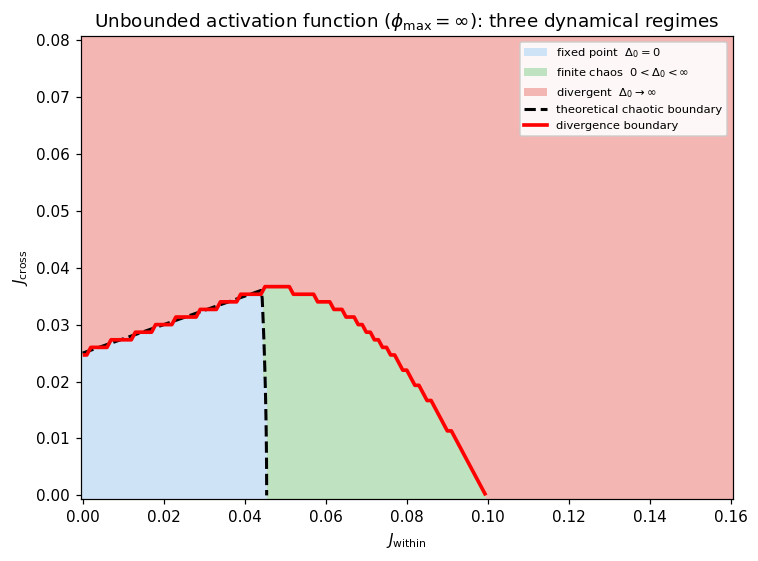

In [8]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

gu = grids_unb
fixed_pt = (~gu['diverged']) & (gu['onset_rho'] < 1.0)
finite_chaos = (~gu['diverged']) & (gu['onset_rho'] >= 1.0)
phase = np.where(gu['diverged'], 2.0, np.where(finite_chaos, 1.0, 0.0))

fig, ax = plt.subplots(figsize=(7.0, 5.2))
ax.pcolormesh(para1, para2, phase.T, shading='auto',
              cmap=ListedColormap(['#cfe3f7', '#bfe3c0', '#f4b6b2']), vmin=0, vmax=2)
ax.contour(para1, para2, gu['stab'].T, levels=[1.0],
           colors='black', linewidths=2.0, linestyles='--')                 # chaos onset
if 0 < gu['diverged'].sum() < gu['diverged'].size:
    ax.contour(para1, para2, gu['diverged'].T.astype(float),
               levels=[0.5], colors='red', linewidths=2.4)                  # divergence
ax.legend(handles=[
    Patch(facecolor='#cfe3f7', label=r'fixed point  $\Delta_0=0$'),
    Patch(facecolor='#bfe3c0', label=r'finite chaos  $0<\Delta_0<\infty$'),
    Patch(facecolor='#f4b6b2', label=r'divergent  $\Delta_0\to\infty$'),
    Line2D([0], [0], color='black', ls='--', lw=2.0, label=r'theoretical chaotic boundary'),
    Line2D([0], [0], color='red', lw=2.4, label=r'divergence boundary'),
], fontsize=7.5, loc='upper right', framealpha=0.9)
ax.set_xlabel(AXIS_X_LABEL); ax.set_ylabel(AXIS_Y_LABEL)
ax.set_title(r'Unbounded activation function ($\phi_{\max}=\infty$): three dynamical regimes')
plt.tight_layout()
plt.savefig("DMFT_phase_diagram_J_cross_J_within.png", dpi=300, bbox_inches="tight")
plt.show()


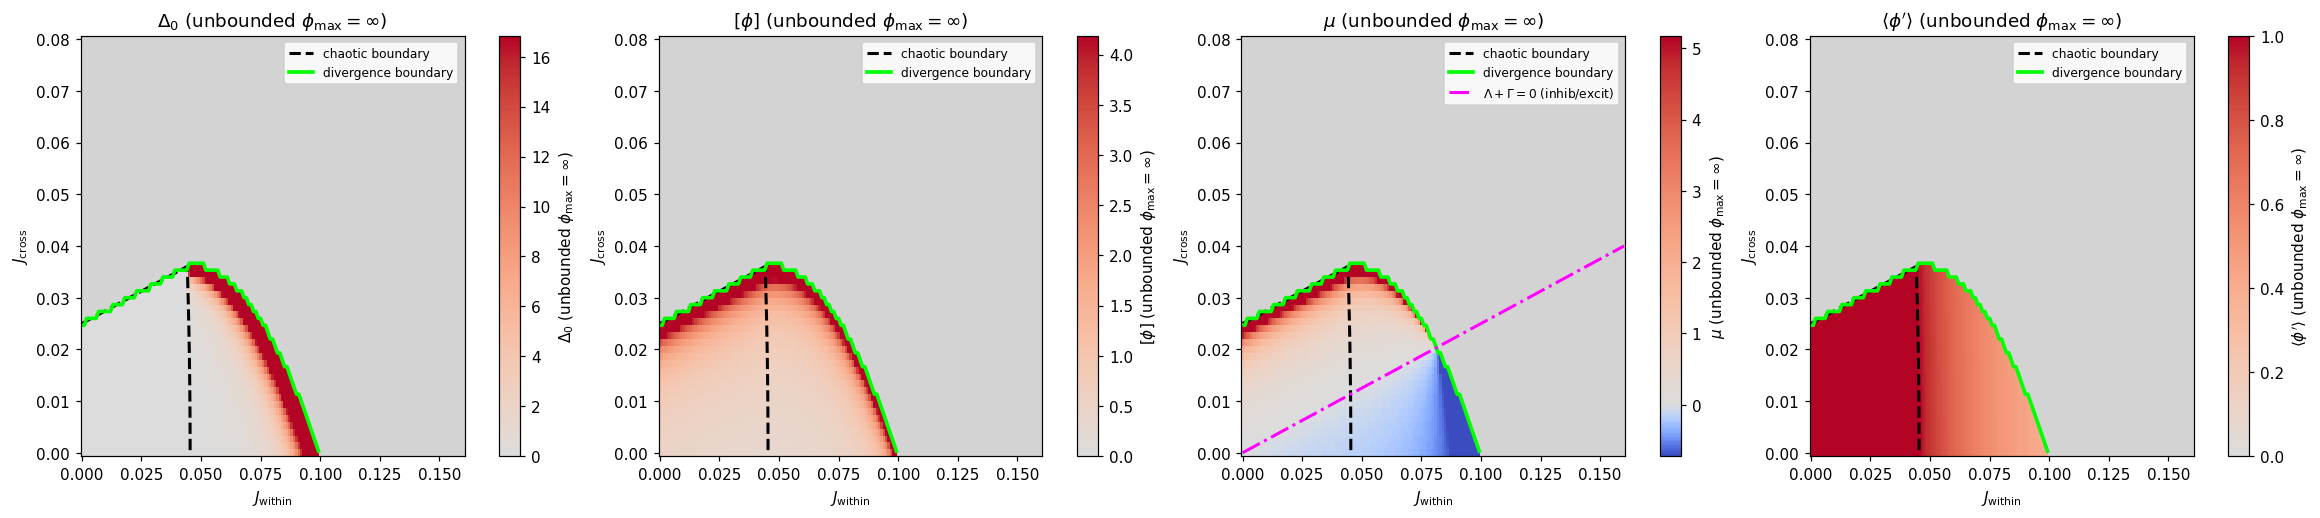

In [9]:
gu = grids_unb
# Unbounded colour maps as one equal-sized row: Delta_0, [phi], mu, <phi'>.
# Diverging coolwarm colorbars pinned at 0 (blue < 0, red > 0); percentile caps.
fig, axes = plt.subplots(1, 4, figsize=(21, 4.6), constrained_layout=True)
_, d0hi = _cap(gu['D0'])
plot_2d(gu['D0'],   r'$\Delta_0$ (unbounded $\phi_{\max}=\infty$)', cmap='coolwarm', center=0.0,
        onset_grid=gu['stab'], boundary_grid=gu['diverged'], vmin=0.0, vmax=d0hi, ax=axes[0])
_, rhi = _cap(gu['rate'])
plot_2d(gu['rate'], r'$[\phi]$ (unbounded $\phi_{\max}=\infty$)', cmap='coolwarm', center=0.0,
        onset_grid=gu['stab'], boundary_grid=gu['diverged'], vmin=0.0, vmax=rhi, ax=axes[1])
mlo, mhi = _cap(gu['mu'], 5.0, 95.0)
plot_2d(gu['mu'],   r'$\mu$ (unbounded $\phi_{\max}=\infty$)', cmap='coolwarm', center=0.0,
        onset_grid=gu['stab'], boundary_grid=gu['diverged'], zero_grid=gu['mu_drive'],
        vmin=mlo, vmax=mhi, ax=axes[2])
plot_2d(gu['phi_prime'], r"$\langle\phi'\rangle$ (unbounded $\phi_{\max}=\infty$)",
        cmap='coolwarm', center=0.0, onset_grid=gu['stab'], boundary_grid=gu['diverged'],
        vmin=0.0, vmax=1.0, ax=axes[3])
plt.savefig("DMFT_color_graphs_J_cross_J_within_unbounded.png", dpi=300, bbox_inches="tight")
plt.show()

## E. Bounded activation function scans

Saturation keeps $\Delta_0$ finite everywhere, so there is **no divergence boundary** -
only the chaos onset (dashed). The fluctuation amplitude grows continuously past the
onset and then bends over as the units saturate.


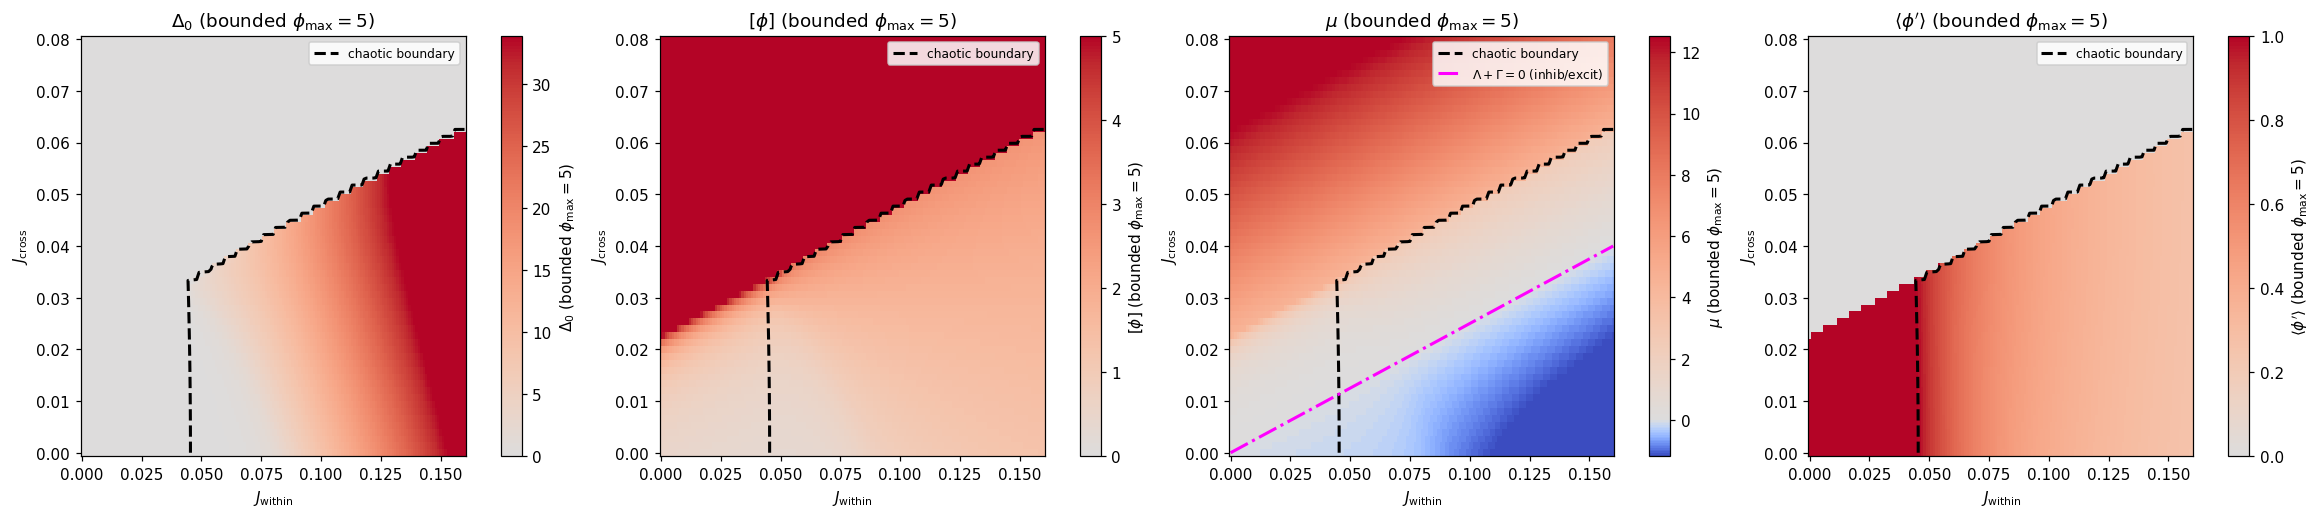

In [10]:
if 5.0 in bounded_grids:
    gb = bounded_grids[5.0]
    # Bounded colour maps as one equal-sized row (chaos onset only; no divergence).
    fig, axes = plt.subplots(1, 4, figsize=(21, 4.6), constrained_layout=True)
    _, d0hi = _cap(gb['D0'])
    plot_2d(gb['D0'],   r'$\Delta_0$ (bounded $\phi_{\max}=5$)', cmap='coolwarm', center=0.0,
            onset_grid=gb['stab'], vmin=0.0, vmax=d0hi, ax=axes[0])
    _, rhi = _cap(gb['rate'])
    plot_2d(gb['rate'], r'$[\phi]$ (bounded $\phi_{\max}=5$)', cmap='coolwarm', center=0.0,
            onset_grid=gb['stab'], vmin=0.0, vmax=rhi, ax=axes[1])
    mlo, mhi = _cap(gb['mu'], 5.0, 95.0)
    plot_2d(gb['mu'],   r'$\mu$ (bounded $\phi_{\max}=5$)', cmap='coolwarm', center=0.0,
            onset_grid=gb['stab'], zero_grid=gb['mu_drive'], vmin=mlo, vmax=mhi, ax=axes[2])
    plot_2d(gb['phi_prime'], r"$\langle\phi'\rangle$ (bounded $\phi_{\max}=5$)",
            cmap='coolwarm', center=0.0, onset_grid=gb['stab'], vmin=0.0, vmax=1.0, ax=axes[3])
    plt.savefig("DMFT_color_graphs_J_cross_J_within_phimax=5.png", dpi=300, bbox_inches="tight")
    plt.show()

## F. Bounded-$\phi$ comprehensive phase diagram (bistable coexistence)

Sections D/E classify each grid point by a **single** forward solve. But with a saturating
$\phi$ the bounded model has a **fold / hysteresis** (studied in
`DMFT_catastrophe_analysis.ipynb`): over a coupling band a **saturated fixed point** and a
**chaotic** solution *coexist*, so which one the network settles into depends on the initial
condition. A single-solve map cannot show this. Here we census **all** stationary solutions at
every grid point and colour the plane by regime.

**Reduced engine (symmetric-subspace reduction).** The default scan is symmetric -- both
within-areas equal and both cross directions equal -- so on the symmetric subspace
$(\mu_0=\mu_1,\ \Delta_{0,0}=\Delta_{0,1})$ the two-area DMFT collapses to a single population
whose effective couplings are the **row sums** of $M_{\rm structure}$ / $M_{\rm random}$
(verified in the solver cell). The stationary equations become
$\ \mu=F(\mu,\Delta_0)=\Lambda_{\rm eff}\,[\phi]+I,\quad
\Delta_0=G(\mu,\Delta_0)=\sqrt{2\,\Sigma_{\rm eff}\,Q}$,
whose intersections are the self-consistent solutions. We count the **stable** ones and tag
each point:

| regime | condition | meaning |
|---|---|---|
| **linear fixed point** | unique stable state is the trivial ($\Delta_0=0$) FP, mostly responsive ($f_{\rm sat}<\tfrac12$) | low coupling, units in the linear band |
| **saturated fixed point** | unique stable state is the trivial FP, mostly clipped ($f_{\rm sat}\ge\tfrac12$) | strong excitatory drive, $\phi\!\approx\!\phi_{\max}$ |
| **chaotic** | the trivial FP is variance-unstable and a nonzero-$\Delta_0$ solution is stable | self-sustained fluctuations |
| **bistable** | the trivial (saturated) FP **and** a chaotic solution are *both* stable | the fold: coexistence / hysteresis |

The census machinery (`effective_couplings`, `F_map`/`G_map`, `mu_star_slaved`, `_mu_profile`,
`_all_roots`, `trivial_stable`, `reduced_jacobian_radius`, `phi_prime_fractions`) is reused
**verbatim** from `DMFT_catastrophe_analysis.ipynb` (its `stationary_solutions` /
`catastrophe_analysis`, already cross-checked there against time-reversed dynamics). The
dashed line is the chaos onset $\mathrm{stab}=1$ carried over from Section E.

In [11]:
# ---- Section F: reduced symmetric-subspace census (ported verbatim from
#      DMFT_catastrophe_analysis.ipynb, cell 16 nullcline + cell 8 phi'-fractions) ----
from scipy.optimize import brentq


def effective_couplings(p):
    """Symmetric-subspace scalars (Lam_eff, Sig_eff, I) = row sums of M_structure / M_random."""
    Ms = build_M_structure(p); Mr = build_M_random(p)
    return float(Ms[0].sum()), float(Mr[0].sum()), float(p.I_ext[0])


def F_map(mu, D0, Lam, I, gamma, phi_max):
    """mu-map: mu = Lam_eff <phi>(mu,D0) + I."""
    return Lam * mean_phi(mu, D0, gamma, phi_max) + I


def G_map(mu, D0, Sig, gamma, phi_max):
    """Delta0-map: D0 = sqrt(2 Sig_eff Q(mu,D0))."""
    return math.sqrt(max(2.0 * Sig * Q_diag(mu, D0, gamma, phi_max), 0.0))


def mu_star_slaved(D0, Lam, I, gamma, phi_max, seed=0.0, eps=0.4, iters=3000, tol=1e-11):
    """Stable fixed point mu = F(mu, D0) by DAMPED iteration from `seed` (same scheme as the
    full solver). Damped iteration only converges to MEAN-stable roots, so mu* is the physical
    (linear or saturated) fixed point; warm-starting `seed` keeps the branch continuous."""
    mu = float(seed)
    for _ in range(iters):
        mu_new = (1.0 - eps) * mu + eps * (Lam * mean_phi(mu, D0, gamma, phi_max) + I)
        if abs(mu_new - mu) < tol:
            mu = mu_new
            break
        mu = mu_new
    return mu


def _all_roots(func, lo, hi, n=250):
    """All roots of `func` on [lo, hi] via sign-change bracketing (captures the multivalued,
    S-shaped Delta0 map near the fold)."""
    xs = np.linspace(lo, hi, n)
    fs = np.array([func(x) for x in xs])
    roots = []
    for i in range(n - 1):
        a, b = fs[i], fs[i + 1]
        if a == 0.0:
            roots.append(float(xs[i]))
        elif np.isfinite(a) and np.isfinite(b) and a * b < 0:
            try:
                roots.append(float(brentq(func, xs[i], xs[i + 1], xtol=1e-12)))
            except ValueError:
                pass
    return roots


def _mu_profile(Lam, I, gamma, phi_max, D0_grid):
    """mu*(D0) along the CONTINUOUS branch, sweeping D0 upward and warm-starting each point."""
    mus = np.empty(len(D0_grid))
    seed = mu_star_slaved(float(D0_grid[0]), Lam, I, gamma, phi_max, seed=0.0)
    for i, D0 in enumerate(D0_grid):
        seed = mu_star_slaved(float(D0), Lam, I, gamma, phi_max, seed=seed)
        mus[i] = seed
    return mus


def trivial_stable(Lam, Sig, I, gamma, phi_max, D0_eval=1e-4):
    """Stability of the trivial Delta0=0 solution via the LINEAR variance criterion
    rho_random = Sig_eff <phi'^2>(mu*) < 1. Returns (mu0, is_stable, rho)."""
    mu0 = mu_star_slaved(0.0, Lam, I, gamma, phi_max, seed=0.0)
    rho = Sig * phi_prime_sq_mean(mu0, gamma, phi_max, D0_eval)
    return mu0, rho < 1.0, rho


def reduced_jacobian_radius(mu, D0, Lam, Sig, I, gamma, phi_max, h=1e-5):
    """Spectral radius of the Jacobian of the reduced map (mu,D0)->(F,G) at a NONZERO
    solution. rho<1 -> that chaotic solution is stable."""
    def Fv(m, d): return F_map(m, d, Lam, I, gamma, phi_max)
    def Gv(m, d): return G_map(m, d, Sig, gamma, phi_max)
    hd = max(h, 1e-5 * max(D0, 1.0))
    lo_d = max(D0 - hd, 0.0); span_d = (D0 + hd) - lo_d
    dFdm = (Fv(mu + h, D0) - Fv(mu - h, D0)) / (2 * h)
    dFdd = (Fv(mu, D0 + hd) - Fv(mu, lo_d)) / span_d
    dGdm = (Gv(mu + h, D0) - Gv(mu - h, D0)) / (2 * h)
    dGdd = (Gv(mu, D0 + hd) - Gv(mu, lo_d)) / span_d
    J = np.array([[dFdm, dFdd], [dGdm, dGdd]])
    return float(np.max(np.abs(np.linalg.eigvals(J))))


def phi_prime_fractions(mu, Delta0, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT):
    """Split the population by the local gain phi'(X), X ~ N(mu, Delta0):
      f_silent    = P(X < -gamma)                   -> phi = 0        (phi'=0)
      f_active    = P(-gamma < X < phi_max - gamma) -> linear band    (phi'=1) == <phi'>
      f_saturated = P(X > phi_max - gamma)          -> phi = phi_max  (phi'=0)."""
    s = math.sqrt(max(float(Delta0), 1e-300))

    def ncdf(t):
        return 0.5 * (1.0 + math.erf(t / SQRT2))

    f_silent = ncdf((-gamma - mu) / s)
    if np.isfinite(phi_max):
        cdf_hi = ncdf((phi_max - gamma - mu) / s)
        f_active = cdf_hi - f_silent
        f_saturated = 1.0 - cdf_hi
    else:
        f_active = 1.0 - f_silent
        f_saturated = 0.0
    return float(f_silent), float(f_active), float(f_saturated)


# regime codes
LIN_FP, SAT_FP, CHAOTIC, BISTABLE = 0, 1, 2, 3
# a genuine coexisting chaotic solution has Delta_0 = O(phi_max); in the SATURATED
# region the sqrt variance map G ~ sqrt(2 Sig Q) has Q -> 0, giving a spurious root of
# H(Delta_0) near Delta_0 = 0 that is NOT a chaotic state. Require Delta_0 > this floor
# (same 1e-2 chaotic-branch threshold used in DMFT_catastrophe_analysis.ipynb).
CHAOTIC_D0_MIN = 1e-2
REGIME_NAMES = {LIN_FP: 'linear FP', SAT_FP: 'saturated FP',
                CHAOTIC: 'chaotic', BISTABLE: 'bistable'}


D0_HI_CAP = 400.0            # hard ceiling on the adaptive Delta_0 search range


def _bracket_D0_hi(Lam, Sig, I, gamma, phi_max, D0_hi):
    """Grow `D0_hi` until it lies PAST the chaotic-branch root, i.e. H(D0_hi) < 0
    (H(D0)=G(mu*(D0),D0)-D0). The chaotic Delta_0 grows without a fixed bound as the coupling
    rises (measured > 50), so a fixed ceiling silently drops the branch and mislabels the point
    as a saturated fixed point. For points with no chaotic branch H(D0_hi) is already < 0, so
    the loop exits immediately and the per-point cost is unchanged."""
    mu_seed = mu_star_slaved(D0_hi, Lam, I, gamma, phi_max, seed=0.0)
    while D0_hi < D0_HI_CAP and G_map(mu_seed, D0_hi, Sig, gamma, phi_max) - D0_hi > 0.0:
        D0_hi = min(D0_hi * 1.6, D0_HI_CAP)
        mu_seed = mu_star_slaved(D0_hi, Lam, I, gamma, phi_max, seed=mu_seed)
    return min(D0_hi * 1.25, D0_HI_CAP)                 # margin past the root


def census_bounded(Lam, Sig, I, gamma, phi_max, D0_hi, n=110):
    """Return (mu0, triv_stable, [stable nonzero Delta0 roots]) for the reduced problem.
    `D0_hi` is a STARTING range; it is grown adaptively so the chaotic branch is always
    bracketed, and the root/mu-profile resolution is scaled to keep the Delta_0 spacing ~0.36."""
    mu0, triv_stab, _ = trivial_stable(Lam, Sig, I, gamma, phi_max)
    D0_hi = _bracket_D0_hi(Lam, Sig, I, gamma, phi_max, D0_hi)
    n = max(n, int(D0_hi / 0.36))
    D0g = np.linspace(0.0, D0_hi, n)
    mus = _mu_profile(Lam, I, gamma, phi_max, D0g)
    muf = lambda D0: float(np.interp(D0, D0g, mus))
    H = lambda D0: G_map(muf(D0), D0, Sig, gamma, phi_max) - D0
    stab_nz = [D0 for D0 in _all_roots(H, 1e-6, D0_hi, n=n)
               if D0 > CHAOTIC_D0_MIN
               and reduced_jacobian_radius(muf(D0), D0, Lam, Sig, I, gamma, phi_max) < 1.0]
    return mu0, triv_stab, stab_nz


def classify_bounded(p, n=110, sat_thr=0.5):
    """Regime of a single (symmetric) MultiAreaParams `p` from the stable-solution census."""
    Lam, Sig, I = effective_couplings(p)
    D0_hi = max(40.0, 8.0 * p.phi_max)                 # STARTING range; grown adaptively in census_bounded
    mu0, triv_stab, stab_nz = census_bounded(Lam, Sig, I, p.gamma, p.phi_max, D0_hi, n=n)
    has_chaos = len(stab_nz) >= 1
    if triv_stab and has_chaos:
        return BISTABLE
    if has_chaos:                                      # trivial FP unstable, chaos stable
        return CHAOTIC
    if triv_stab:                                      # unique fixed point: linear vs saturated
        _, _, f_sat = phi_prime_fractions(mu0, 0.0, p.gamma, p.phi_max)
        return SAT_FP if f_sat >= sat_thr else LIN_FP
    return CHAOTIC                                     # neither stable (rare numerical edge)


bounded phi_max=5 phase diagram (161x61 = 9821 points):
   linear FP        985  (10.0%)
   saturated FP    3827  (39.0%)
   chaotic         4231  (43.1%)
   bistable         778  (7.9%)
   max chaotic Delta_0 found = 53.8  (adaptive range cap = 400)
bistable extent:  J_within [0.0540, 0.1600]  x  J_cross [0.0360, 0.0800]
   fold window at J_within=0.100:  J_cross in [0.0480, 0.0547]  (catastrophe nb: [0.0476, 0.0559])


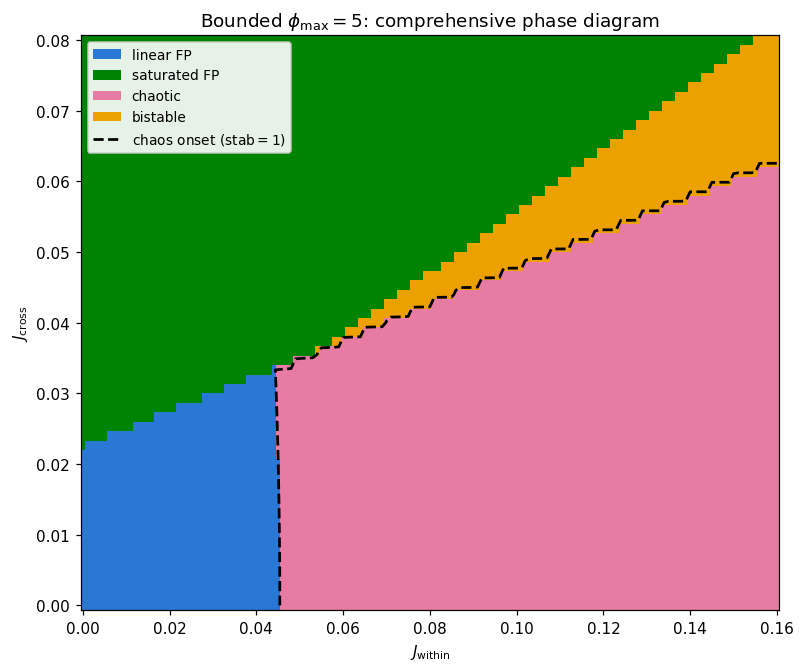

In [12]:
# ---- Section F: bounded-phi phase diagram over the SAME AXIS_X x AXIS_Y grid ----
PHASE_PHI_MAX = 5.0            # bounded activation function used for the phase diagram
CENSUS_N = 110                # Delta0-root resolution of the census (validated)

# The symmetric-subspace reduction requires identical areas and cross directions; warn if the
# active scan is asymmetric (then this diagram is only an approximation).
_pc = apply_updates_to_params(base_p, {**scan_updates(float(AXIS_X['values'][-1]),
                                                       float(AXIS_Y['values'][-1])),
                                        'phi_max': PHASE_PHI_MAX})
if (_pc.areas[0] != _pc.areas[1] or _pc.J_cross[0, 1] != _pc.J_cross[1, 0]
        or _pc.C_cross[0, 1] != _pc.C_cross[1, 0]):
    print('WARNING: active scan is ASYMMETRIC -- the symmetric-subspace phase diagram is only '
          'approximate. Use a symmetric scan_updates for an exact 4-regime map.')

nx, ny = len(AXIS_X['values']), len(AXIS_Y['values'])
region = np.zeros((nx, ny), dtype=int)
max_chaotic_D0 = 0.0
scan_points = (scan_updates(float(xv), float(yv))
               for xv, yv in product(AXIS_X['values'], AXIS_Y['values']))
for idx, updates in enumerate(scan_points):
    i, j = divmod(idx, ny)
    p = apply_updates_to_params(base_p, {**updates, 'phi_max': PHASE_PHI_MAX})
    _Lam, _Sig, _I = effective_couplings(p)
    _mu0, _ts, _nz = census_bounded(_Lam, _Sig, _I, p.gamma, p.phi_max,
                                    max(40.0, 8.0 * p.phi_max), n=CENSUS_N)
    _has = len(_nz) >= 1
    if _ts and _has:
        region[i, j] = BISTABLE
    elif _has:
        region[i, j] = CHAOTIC
    elif _ts:
        _, _, _fsat = phi_prime_fractions(_mu0, 0.0, p.gamma, p.phi_max)
        region[i, j] = SAT_FP if _fsat >= 0.5 else LIN_FP
    else:
        region[i, j] = CHAOTIC
    if _has:
        max_chaotic_D0 = max(max_chaotic_D0, max(_nz))

# ---- report ----
counts = {k: int(np.sum(region == k)) for k in REGIME_NAMES}
print('bounded phi_max=%g phase diagram (%dx%d = %d points):' % (PHASE_PHI_MAX, nx, ny, region.size))
for k in (LIN_FP, SAT_FP, CHAOTIC, BISTABLE):
    print('   %-14s %5d  (%.1f%%)' % (REGIME_NAMES[k], counts[k], 100 * counts[k] / region.size))
print('   max chaotic Delta_0 found = %.1f  (adaptive range cap = %.0f)'
      % (max_chaotic_D0, D0_HI_CAP))
_bi, _bj = np.where(region == BISTABLE)
if _bi.size:
    print('bistable extent:  J_within [%.4f, %.4f]  x  J_cross [%.4f, %.4f]'
          % (para1[_bi].min(), para1[_bi].max(), para2[_bj].min(), para2[_bj].max()))
    # self-check on the J_within=0.10 line (catastrophe notebook fold window ~ [0.0476, 0.0559])
    _c = int(np.argmin(np.abs(para1 - 0.10)))
    _jc = para2[region[_c] == BISTABLE]
    if _jc.size:
        print('   fold window at J_within=%.3f:  J_cross in [%.4f, %.4f]  '
              '(catastrophe nb: [0.0476, 0.0559])' % (para1[_c], _jc.min(), _jc.max()))

# ---- figure: 4-regime categorical map (palette = dataviz validated first-4 categorical) ----
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

REGIME_COLORS = {LIN_FP: '#2a78d6',    # blue   -- linear fixed point
                 SAT_FP: '#008300',    # green  -- saturated fixed point
                 CHAOTIC: '#e87ba4',   # magenta-- chaotic
                 BISTABLE: '#eda100'}  # yellow -- bistable (highlighted thin band)
cmap = ListedColormap([REGIME_COLORS[k] for k in (LIN_FP, SAT_FP, CHAOTIC, BISTABLE)])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

fig, ax = plt.subplots(figsize=(7.2, 6.0), constrained_layout=True)
ax.pcolormesh(para1, para2, region.T, cmap=cmap, norm=norm, shading='auto')

# chaos-onset stab=1 line carried over from Section E (boundary of the chaotic region)
if PHASE_PHI_MAX in bounded_grids:
    _stab = bounded_grids[PHASE_PHI_MAX]['stab']
    if np.nanmin(_stab) < 1.0 < np.nanmax(_stab):
        ax.contour(para1, para2, _stab.T, levels=[1.0], colors='black',
                   linewidths=1.8, linestyles='--')

handles = [Patch(facecolor=REGIME_COLORS[k], edgecolor='none', label=REGIME_NAMES[k])
           for k in (LIN_FP, SAT_FP, CHAOTIC, BISTABLE)]
handles.append(plt.Line2D([0], [0], color='black', ls='--', lw=1.8, label=r'chaos onset (stab$=1$)'))
ax.legend(handles=handles, fontsize=9, loc='upper left', framealpha=0.9)
ax.set_xlabel(AXIS_X_LABEL); ax.set_ylabel(AXIS_Y_LABEL)
ax.set_title(r'Bounded $\phi_{\max}=%g$: comprehensive phase diagram' % PHASE_PHI_MAX)
plt.savefig('DMFT_bounded_phase_diagram.png', dpi=300, bbox_inches='tight')
plt.show()


## E$\mu$. $\mu$-divergence 2-D scan ($\mu$ as the ending criterion)

The same unbounded scan as Section D, but the ONLY divergence/ending criterion is
$\mu\to\infty$ (via `mu_cap`); a $\Delta_0$ blow-up is soft-capped (`D0_soft`) and NOT treated
as divergence. This isolates the **structural mean runaway** (the excitatory-dominated
instability, $\Lambda+\Gamma>0$) from the variance blow-up mapped in Section D. Like the
$\Delta_0$ boundary's dependence on `D0_cap`, the $\mu$-divergence boundary depends on `D0_soft`.

In [13]:
def solve_selfconsistent_mucrit(p, mu0=None, D0_0=None, eps=0.1, tol=1e-7,
                                max_iter=400_000, mu_cap=1e6, D0_overflow=1e16):
    """Self-consistent DMFT with mu-divergence as the ONLY ending criterion.

    Identical iteration to `solve_selfconsistent` (validated against Pan2/Three/Jdep.py);
    the difference is purely the stopping rule:
      * Delta_0 is NOT capped as a divergence criterion -- it evolves freely (a large
        Delta_0 is allowed), with `D0_overflow` only as a numerical-overflow guard;
      * divergence is flagged when |mu| exceeds `mu_cap`, mu/Delta_0 go non-finite, or the
        damped iteration fails to converge within `max_iter` (a genuine solution converges;
        a run-away one does not).
    `max_iter` is deliberately LARGE: convergence critically slows down near the transition
    (measured worst case 153,304 iterations at J_within=0.045, J_cross=0.021), and a cap that
    is too small mislabels those merely-slow points as divergent, leaving isolated specks in
    the maps. With 400k the only points left non-converged are true run-aways -- chiefly the
    marginal Lambda+Gamma=1 line, where mu drifts upwards without bound.
    For the UNBOUNDED rectifier this is the physically correct behaviour: past the chaotic
    transition Delta_0 -> infinity drags <phi> ~ sqrt(Delta_0) -> infinity, hence
    mu = (Lambda+Gamma)<phi> -> -infinity when the net drive is inhibition-dominated
    (Lambda+Gamma < 0) and -> +infinity when it is excitation-dominated. `mu_sign` records
    which. (Mastrogiuseppe & Ostojic 2017, Fig. 3.)"""
    Mstruct = build_M_structure(p); Mrand = build_M_random(p)
    A = len(p.areas); g_, pm = p.gamma, p.phi_max
    mu = np.array([-0.1] * A if mu0 is None else mu0, dtype=float)
    D0 = np.array([1.0] * A if D0_0 is None else D0_0, dtype=float)
    conv = False; hit_cap = False; it = 0
    for it in range(max_iter):
        ph = np.empty(A); Q = np.empty(A)
        for a in range(A):
            pa, Pa, P2a = gaussian_stats(mu[a], D0[a], g_, pm)
            ph[a] = pa; Q[a] = max(P2a - Pa * Pa - D0[a] * pa * pa, 0.0)
        mu_new = (1 - eps) * mu + eps * (Mstruct @ ph + p.I_ext)
        D0_target = np.sqrt(np.maximum(2.0 * (Mrand @ Q), 0.0))
        D0_new = np.where(D0 > 0.0, (1 - eps) * D0 + eps * D0_target, (1 - eps) * D0)
        D0_new = np.maximum(D0_new, 0.0)                 # NO soft cap on Delta_0
        if (not np.all(np.isfinite(mu_new)) or not np.all(np.isfinite(D0_new))
                or np.max(np.abs(mu_new)) > mu_cap or np.max(D0_new) > D0_overflow):
            hit_cap = True; mu = mu_new; break
        conv = (np.max(np.abs(mu - mu_new)) < tol) and (np.max(np.abs(D0 - D0_new)) < tol)
        mu, D0 = mu_new, D0_new
        if conv:
            break
    mu_diverged = bool(hit_cap or (not conv))            # non-convergence == still running away
    rate = np.array([mean_phi(mu[a], D0[a], g_, pm) for a in range(A)]) if not mu_diverged \
        else np.full(A, np.nan)
    return dict(mu=mu, Delta0=D0, rate=rate, mu_diverged=mu_diverged,
                mu_sign=(int(np.sign(mu[0])) if mu_diverged else 0),
                converged=conv, n_iter=it + 1)


def solve_point_mucrit(p):
    """Per-point observables under the mu-divergence criterion. Seeded NEUTRALLY with Pan2's
    initial condition (mu=-0.1, Delta_0=1) -- never `fixed_point_mu`, whose 1e8 runaway guard
    would pre-flag divergence before the self-consistent problem is ever solved."""
    sol = solve_selfconsistent_mucrit(p, mu0=np.array([-0.1, -0.1]), D0_0=np.array([1.0, 1.0]))
    if sol['mu_diverged']:
        return dict(D0=np.nan, rate=np.nan, mu=np.nan, phi_prime=np.nan,
                    mu_diverged=True, mu_sign=sol['mu_sign'])
    d0, mm = float(sol['Delta0'][0]), float(sol['mu'][0])
    return dict(D0=d0, rate=float(sol['rate'][0]), mu=mm,
                phi_prime=mean_phi_prime(mm, d0, p.gamma, p.phi_max),
                mu_diverged=False, mu_sign=0)


def run_scan_mucrit(phi_max=np.inf):
    """2-D scan (default unbounded) whose ONLY divergence/ending criterion is mu -> infinity.
    Returns grids D0/rate/mu/phi_prime, the boolean `mu_diverged` mask, `mu_sign`
    (-1: mu -> -inf, +1: mu -> +inf, 0: converged) and `mu_drive` (= Lambda+Gamma)."""
    nx, ny = len(AXIS_X["values"]), len(AXIS_Y["values"])
    keys = ('D0', 'rate', 'mu', 'phi_prime')
    G = {k: np.zeros((nx, ny)) for k in keys}
    mu_diverged = np.zeros((nx, ny), dtype=bool)
    mu_sign = np.zeros((nx, ny)); mu_drive = np.zeros((nx, ny))
    scan_points = (scan_updates(float(xv), float(yv))
                   for xv, yv in product(AXIS_X["values"], AXIS_Y["values"]))
    for idx, updates in enumerate(scan_points):
        i, j = divmod(idx, ny)
        p = apply_updates_to_params(base_p, {**updates, "phi_max": phi_max})
        r = solve_point_mucrit(p)
        for k in keys:
            G[k][i, j] = r[k]
        mu_diverged[i, j] = r['mu_diverged']; mu_sign[i, j] = r['mu_sign']
        mu_drive[i, j] = float(build_M_structure(p).sum(axis=1)[0])
    return dict(mu_diverged=mu_diverged, mu_sign=mu_sign, mu_drive=mu_drive,
                phi_max=phi_max, **G)


grids_mu = run_scan_mucrit(np.inf)   # unbounded, mu-divergence ending criterion
_neg = (grids_mu['mu_sign'] < 0); _pos = (grids_mu['mu_sign'] > 0)
print('mu-criterion: mu-divergent %.3f  (mu->-inf %.3f | mu->+inf %.3f)   '
      'vs Delta0-criterion divergent %.3f'
      % (grids_mu['mu_diverged'].mean(), _neg.mean(), _pos.mean(), grids_unb['diverged'].mean()))
print('sign split vs the Lambda+Gamma=0 line:  max(Lambda+Gamma) where mu->-inf = %.3f  |  '
      'min(Lambda+Gamma) where mu->+inf = %.3f'
      % (grids_mu['mu_drive'][_neg].max() if _neg.any() else np.nan,
         grids_mu['mu_drive'][_pos].min() if _pos.any() else np.nan))

mu-criterion: mu-divergent 0.786  (mu->-inf 0.171 | mu->+inf 0.615)   vs Delta0-criterion divergent 0.787
sign split vs the Lambda+Gamma=0 line:  max(Lambda+Gamma) where mu->-inf = 0.000  |  min(Lambda+Gamma) where mu->+inf = 0.003


In [14]:
# ---- UNBOUNDED single-area reduction (J_cross=0): the paper's Fig. 3, mu -> -infinity ----print("(b) UNBOUNDED, J_cross=0: mu must run away to -infinity (Lambda = J(C_E-g*C_I) < 0)")
print(f"{'J_within':>9} | {'mu':>13} {'Delta_0':>13} | {'mu_diverged':>12} {'sign':>5}")
for _J in [0.05, 0.09, 0.095, 0.098, 0.100, 0.105, 0.12]:
    _p = apply_updates_to_params(base_p, {"areas[0].J_exc": _J, "areas[1].J_exc": _J,
                                          "J_cross[0,1]": 0.0, "J_cross[1,0]": 0.0,
                                          "phi_max": np.inf})
    _s = solve_selfconsistent_mucrit(_p)
    print(f"{_J:9.3f} | {_s['mu'][0]:13.4g} {_s['Delta0'][0]:13.4g} | "
          f"{str(_s['mu_diverged']):>12} {_s['mu_sign']:+5d}")

 J_within |            mu       Delta_0 |  mu_diverged  sign
    0.050 |       -0.1707       0.06624 |        False    +0
    0.090 |       -0.9142         9.223 |        False    +0


    0.095 |        -1.853         41.54 |        False    +0


    0.098 |        -4.741           286 |        False    +0


    0.100 |        -1e+06     1.313e+13 |         True    -1
    0.105 |    -1.002e+06     1.263e+13 |         True    -1
    0.120 |    -1.007e+06     1.141e+13 |         True    -1


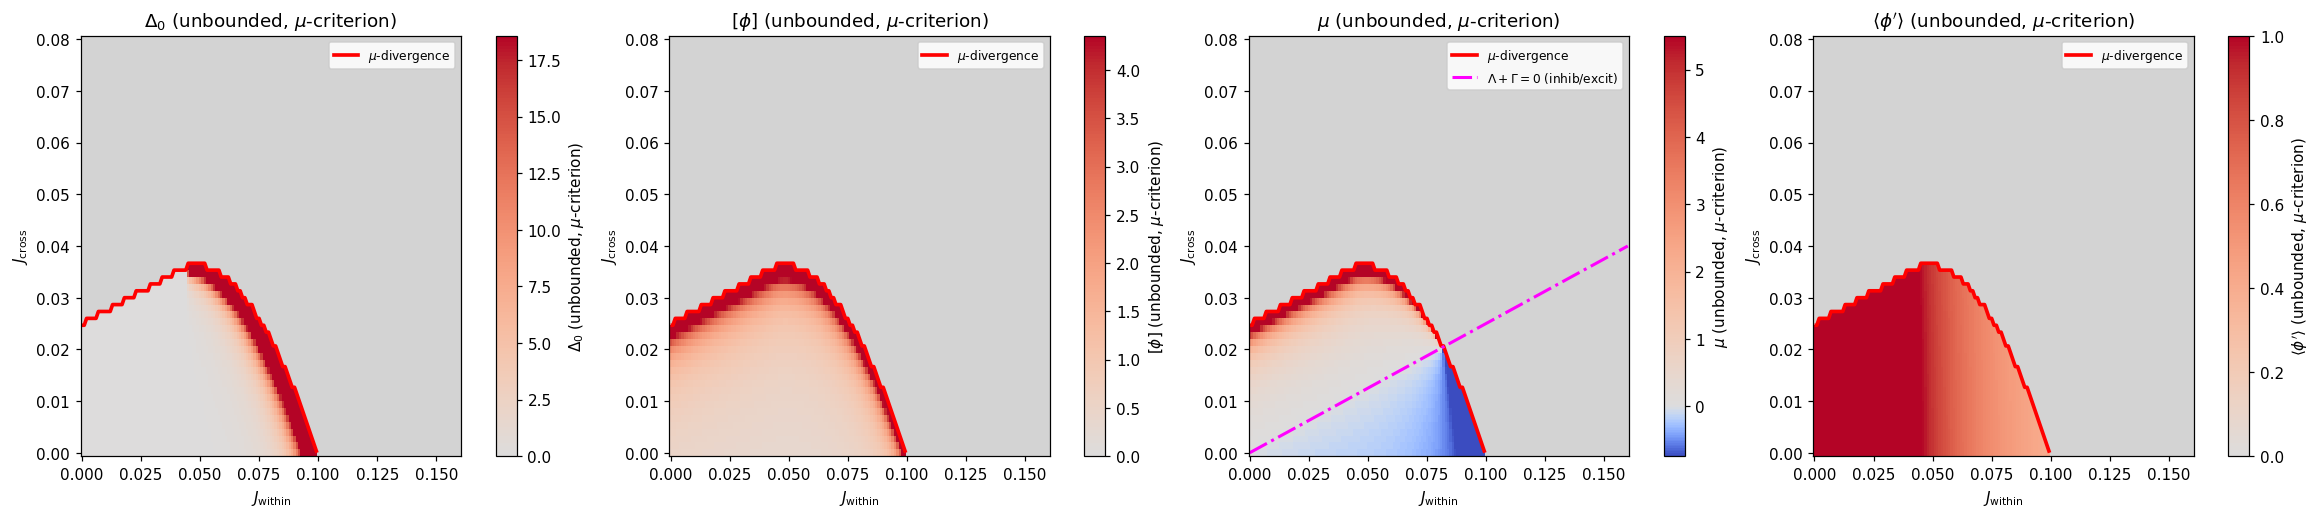

In [15]:
gm = grids_mu
# Same observables as Section D, but the greyed region / red boundary is mu-divergence
# (|mu| -> infinity), NOT Delta_0 blow-up.
fig, axes = plt.subplots(1, 4, figsize=(21, 4.6), constrained_layout=True)
_, d0hi = _cap(gm['D0'])
plot_2d(gm['D0'],   r'$\Delta_0$ (unbounded, $\mu$-criterion)', cmap='coolwarm', center=0.0,
        boundary_grid=gm['mu_diverged'], boundary_color='red', boundary_label=r'$\mu$-divergence',
        vmin=0.0, vmax=d0hi, ax=axes[0])
_, rhi = _cap(gm['rate'])
plot_2d(gm['rate'], r'$[\phi]$ (unbounded, $\mu$-criterion)', cmap='coolwarm', center=0.0,
        boundary_grid=gm['mu_diverged'], boundary_color='red', boundary_label=r'$\mu$-divergence',
        vmin=0.0, vmax=rhi, ax=axes[1])
mlo, mhi = _cap(gm['mu'], 5.0, 95.0)
plot_2d(gm['mu'],   r'$\mu$ (unbounded, $\mu$-criterion)', cmap='coolwarm', center=0.0,
        boundary_grid=gm['mu_diverged'], boundary_color='red', boundary_label=r'$\mu$-divergence',
        zero_grid=gm['mu_drive'], vmin=mlo, vmax=mhi, ax=axes[2])
plot_2d(gm['phi_prime'], r"$\langle\phi'\rangle$ (unbounded, $\mu$-criterion)", cmap='coolwarm',
        center=0.0, boundary_grid=gm['mu_diverged'], boundary_color='red',
        boundary_label=r'$\mu$-divergence', vmin=0.0, vmax=1.0, ax=axes[3])
plt.savefig("DMFT_mu_divergence_scan.png", dpi=300, bbox_inches="tight")
plt.show()

---
### Notes
* **Self-consistency.** $\mu_a$, $\Delta_a^0$, $M_{\rm random}$ are *outputs* of the
  micro-parameters, via the damped fixed-point iteration (Pan2's `Iteration`, two areas).
* **Two stability boundaries.** Chaos onset = $\max(\rho_{\rm rand},\lambda_{\rm struct})=1$
  (variance OR structural). Divergence (unbounded $\phi$) = self-consistent $\Delta_0\to\infty$,
  detected at $\Delta_0\ge D_0^{\rm cap}=10^4$; it lies above the chaos onset, with a
  finite-chaos band between, and merges with the structural boundary at high $J_{\rm cross}$.
* **Bounded vs unbounded.** Saturation (finite $\phi_{\max}$) bounds $\Delta_0$, so the bounded
  maps have a chaos onset but no divergence; the unbounded model diverges past the boundary.
* **Asymmetric areas.** `solve_selfconsistent` / `linear_onsets` already handle independent
  $\mu_a,\Delta_a^0$ per area; pass a `MultiAreaParams` with differing `AreaParams`/`J_cross`.